In [1]:
!pip install -r ../requirements.txt

In [2]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())

12.8
True


In [3]:
import sys
import importlib
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_agent_lstm as d3qn_per_agent
import configurations.config_p2_sub5 as config

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config)

device used:  cuda
device used:  cuda


<module 'configurations.config_p2_sub5' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p2_sub5.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_agent_lstm import D3QN_PER
from configurations.config_p2_sub5 import config

In [5]:
import sequenceReplayBuffer
print(sequenceReplayBuffer.__file__)
import inspect
print(inspect.getsource(sequenceReplayBuffer.SeqReplayBuffer.sample))

c:\Users\hgoel\MTech_Resources\DRL\Capstone_Project\CS780-OBELIX\run_scripts\..\sequenceReplayBuffer.py
    def sample(self, **kwargs):
        priorities = np.array(self.prioritiesOverEpisodes, dtype=np.float32)

        # clean priorities
        priorities = np.nan_to_num(priorities, nan=1e-6, posinf=1.0, neginf=1e-6)
        priorities = np.abs(priorities) + 1e-6

        probs = priorities ** self.alpha

        # clean probs
        probs = np.nan_to_num(probs, nan=0.0, posinf=1.0, neginf=0.0)

        prob_sum = probs.sum()

        if prob_sum <= 0 or not np.isfinite(prob_sum):
            probs = np.ones(len(probs)) / len(probs)
        else:
            probs = probs / prob_sum

        batch_experiences = []
        batch_weights = []
        start_indices = []

        N = self.length()
        batch = min(self.batchSize, N)

        indices = np.random.choice(N, batch, replace=True, p=probs)

        updatedBeta = min(1.0, self.beta + self.beta_rate * kwargs['running_step'

In [6]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 64, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.001, 'MAX_TRAIN_EPISODES': 300, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 50, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x000001D80119C040>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x000001D80115BF60>, 'max_steps': 1000, 'epochs': 20, 'epsilon': 0.58, 'eps_decay_strategy': [('exponential', {'s': 0, 'e': 299, 'ival': 1.0, 'fval': 0.005})], 'device': device(type='cuda'), 'delta': 0.99, 'tau': 0.01, 'alpha': 0.58, 'beta': 0.42, 'beta_rate': 0.0002, 'f_hDim': [512, 256], 'lstm_hDim': 128, 'model_path': '../model_weights_phase2_sub5', 'loss_fn': 'HuberLoss', 'seq_len': 40, 'burn_in': 20, 'minSamples': 2}


In [ ]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=True,
    difficulty=2
)
d3qnPerwithLSTMAgent = D3QN_PER(env, config)

In [8]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerwithLSTMAgent.runD3QN_PER()

Episode 0: TR -8175.0 | ER -115633.4 | TT 9.658775091171265 | WC 41.14803910255432 | TS 1000
Episode 1: TR -54171.0 | ER -180058.4 | TT 48.932332277297974 | WC 89.73373746871948 | TS 1000
Episode 2: TR -17579.0 | ER -197267.4 | TT 102.87237620353699 | WC 142.5501651763916 | TS 1000
Episode 3: TR -51372.0 | ER -985.2 | TT 155.91694521903992 | WC 194.77545309066772 | TS 1000
Episode 4: TR -17574.0 | ER -977.0 | TT 220.8584144115448 | WC 295.66313767433167 | TS 1000
Episode 5: TR -6781.0 | ER -989.2 | TT 319.64016819000244 | WC 394.5244953632355 | TS 1000
Episode 6: TR -63374.0 | ER -984.8 | TT 419.84993028640747 | WC 491.36087369918823 | TS 1000
Episode 7: TR -975.0 | ER -996.8 | TT 504.45686435699463 | WC 559.8348450660706 | TS 1000
Episode 8: TR -6369.0 | ER -39927.4 | TT 584.2383797168732 | WC 654.7546286582947 | TS 1000
Episode 9: TR -10872.0 | ER -982.8 | TT 679.8854451179504 | WC 753.2462918758392 | TS 1000
Episode 10: TR -33167.0 | ER -40947.8 | TT 776.9747774600983 | WC 848.92655

In [9]:
import numpy as np
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -984.6


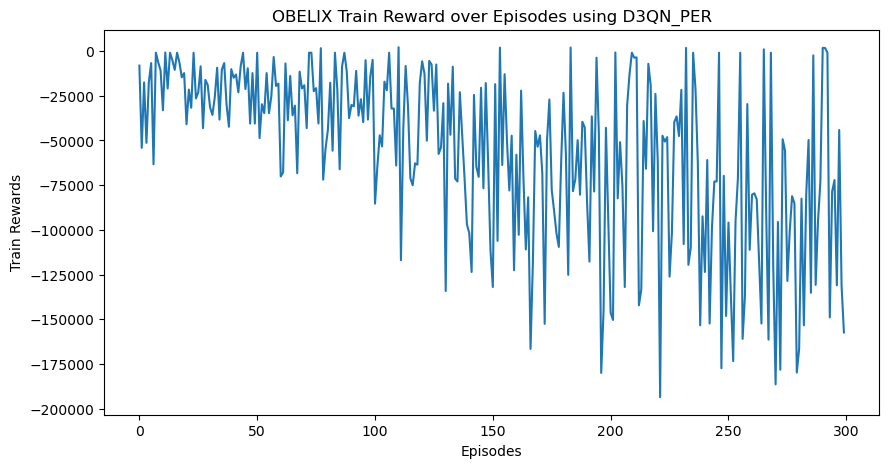

In [10]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

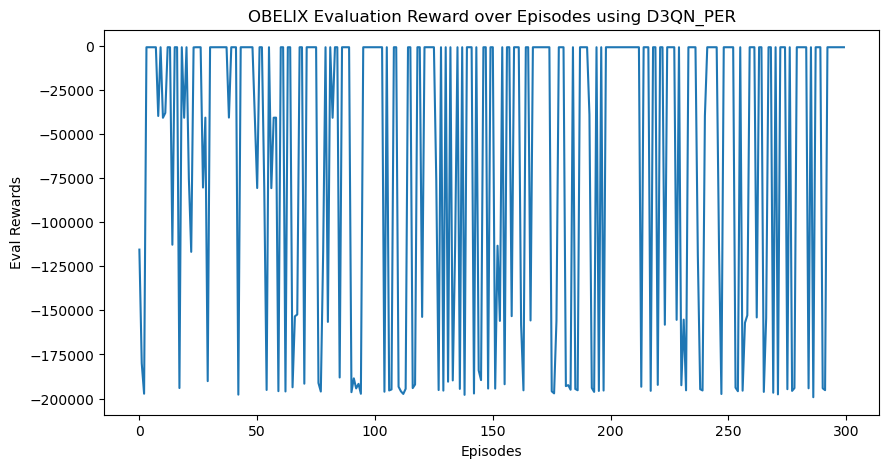

In [11]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

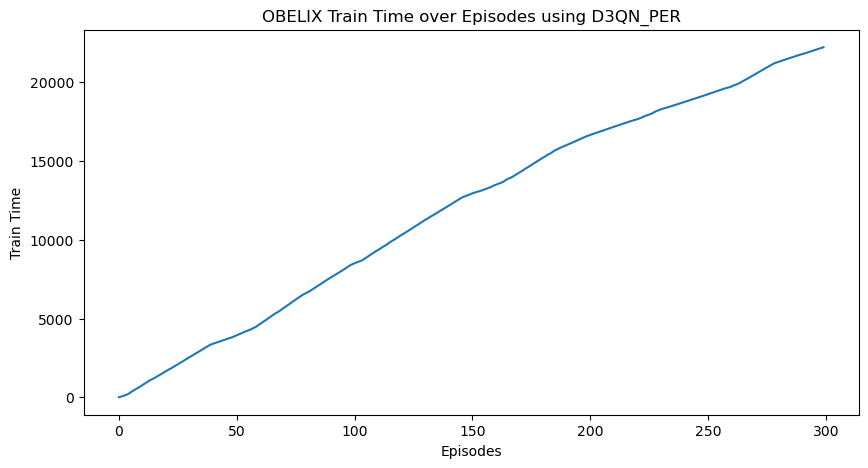

In [12]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

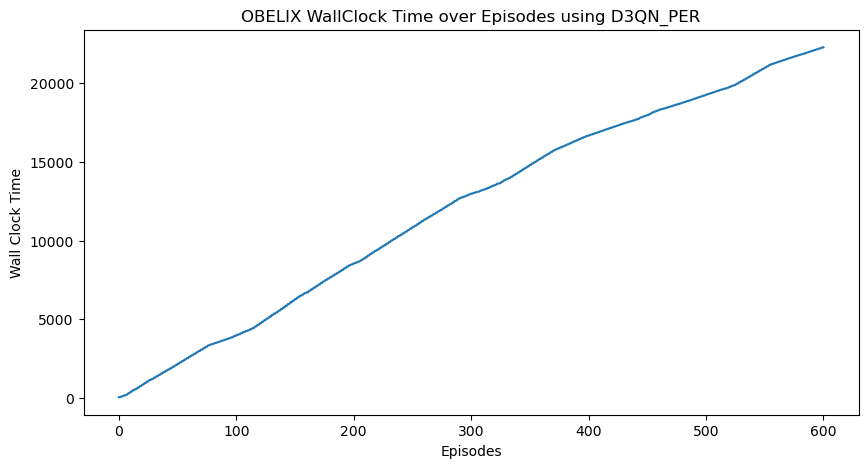

In [13]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

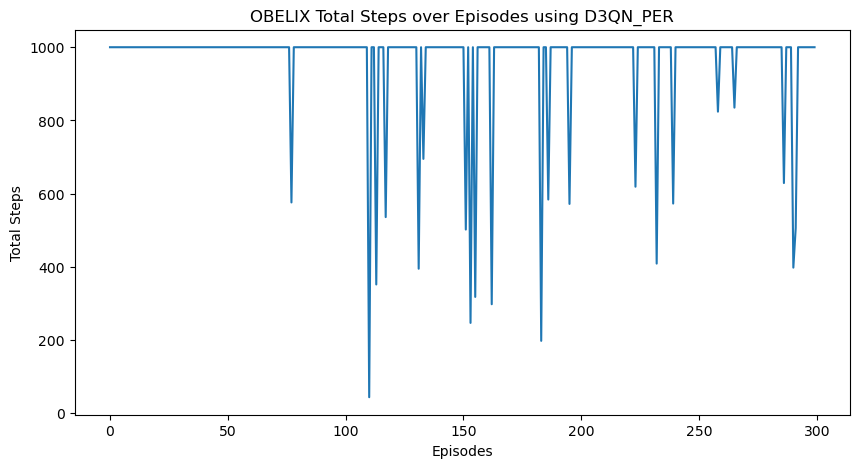

In [14]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)